# Global Air Pollution EDA with tseda

**Dataset:** `data/sample/global air pollution dataset.csv`
23 463 cities × 5 pollutants (AQI, CO, Ozone, NO₂, PM2.5)

**Strategy:** aggregate to country-level mean PM2.5 AQI (175 countries),
sort from most to least polluted, and attach a monthly `DatetimeIndex`
(Jan 2010 → Jul 2024).

All eleven `tseda` modules are demonstrated in order.
HTML reports are saved to `html/`.


## 0 · Setup

In [1]:
%matplotlib inline
import sys, os, warnings, logging
sys.path.insert(0, os.path.abspath(".."))

# suppress all warnings from every library
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tseda import TimeSeries
from tseda.visualization import set_style
set_style()

# ── output directory for HTML reports ──────────────────────────────────────
HTML_DIR = "html"
os.makedirs(HTML_DIR, exist_ok=True)

def report_html(ts, stem, **kw):
    """Generate an HTML EDA report to html/ and return the path."""
    from tseda.report import HTMLReport
    path = os.path.join(HTML_DIR, f"{stem}.html")
    HTMLReport().generate(ts, path, **kw)
    return path

DATA = os.path.join("..", "data", "sample", "global air pollution dataset.csv")
print("Setup complete ✓  |  html/ directory ready")

Setup complete ✓  |  html/ directory ready


## 1 · Data Loading and Exploration

In [2]:
raw = pd.read_csv(DATA, encoding="utf-8-sig")
print(f"Shape : {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head(3)

Shape : (23463, 12)
Columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate


In [3]:
numeric_cols = ["AQI Value", "CO AQI Value", "Ozone AQI Value",
                "NO2 AQI Value", "PM2.5 AQI Value"]
raw[numeric_cols].describe().round(2)

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.00,23463.00,23463.00,23463.00,23463.00
mean,72.01,1.37,35.19,3.06,68.52
std,56.06,1.83,28.10,5.25,54.80
min,6.00,0.00,0.00,0.00,0.00
25%,39.00,1.00,21.00,0.00,35.00
50%,55.00,1.00,31.00,1.00,54.00
75%,79.00,1.00,40.00,4.00,79.00
max,500.00,133.00,235.00,91.00,500.00


In [4]:
print("AQI category distribution:")
print(raw["AQI Category"].value_counts().to_string())

AQI category distribution:
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191


In [5]:
country = (raw.groupby("Country")[numeric_cols]
              .mean().round(2)
              .sort_values("PM2.5 AQI Value", ascending=False)
              .reset_index())
print(f"Countries: {len(country)}")
print("\nTop 10 most polluted (PM2.5):")
print(country[["Country","PM2.5 AQI Value","AQI Value"]].head(10).to_string(index=False))
print("\nTop 10 cleanest (PM2.5):")
print(country[["Country","PM2.5 AQI Value","AQI Value"]].tail(10).to_string(index=False))

Countries: 175

Top 10 most polluted (PM2.5):
             Country  PM2.5 AQI Value  AQI Value
   Republic of Korea           415.00     421.00
             Bahrain           188.00     188.00
          Mauritania           179.00     179.00
            Pakistan           173.11     178.79
               Aruba           163.00     163.00
              Kuwait           162.00     162.00
United Arab Emirates           152.67     163.67
             Senegal           152.42     152.42
               India           149.46     152.96
        Saudi Arabia           149.29     149.29

Top 10 cleanest (PM2.5):
         Country  PM2.5 AQI Value  AQI Value
         Andorra            22.00      29.33
         Uruguay            21.69      26.65
         Finland            21.63      38.37
          Sweden            21.04      36.16
Papua New Guinea            20.53      24.87
          Norway            18.57      35.48
         Iceland            18.33      23.00
        Maldives            1

In [6]:
n   = len(country)
idx = pd.date_range("2010-01-01", periods=n, freq="MS")

ts_pm25  = TimeSeries(country["PM2.5 AQI Value"].values,  index=idx, name="PM2.5 AQI")
ts_aqi   = TimeSeries(country["AQI Value"].values,         index=idx, name="AQI")
ts_no2   = TimeSeries(country["NO2 AQI Value"].values,     index=idx, name="NO2 AQI")
ts_ozone = TimeSeries(country["Ozone AQI Value"].values,   index=idx, name="Ozone AQI")
ts_co    = TimeSeries(country["CO AQI Value"].values,      index=idx, name="CO AQI")
all_series = [ts_pm25, ts_aqi, ts_no2, ts_ozone, ts_co]
print(ts_pm25)

TimeSeries(
  name        : PM2.5 AQI
  n           : 175
  start       : 2010-01-01 00:00:00
  end         : 2024-07-01 00:00:00
  duration    : 5295 days 00:00:00
  freq        : MS (Monthly (start))
  is_regular  : False
  has_nan     : False (0 / 0.0%)
)


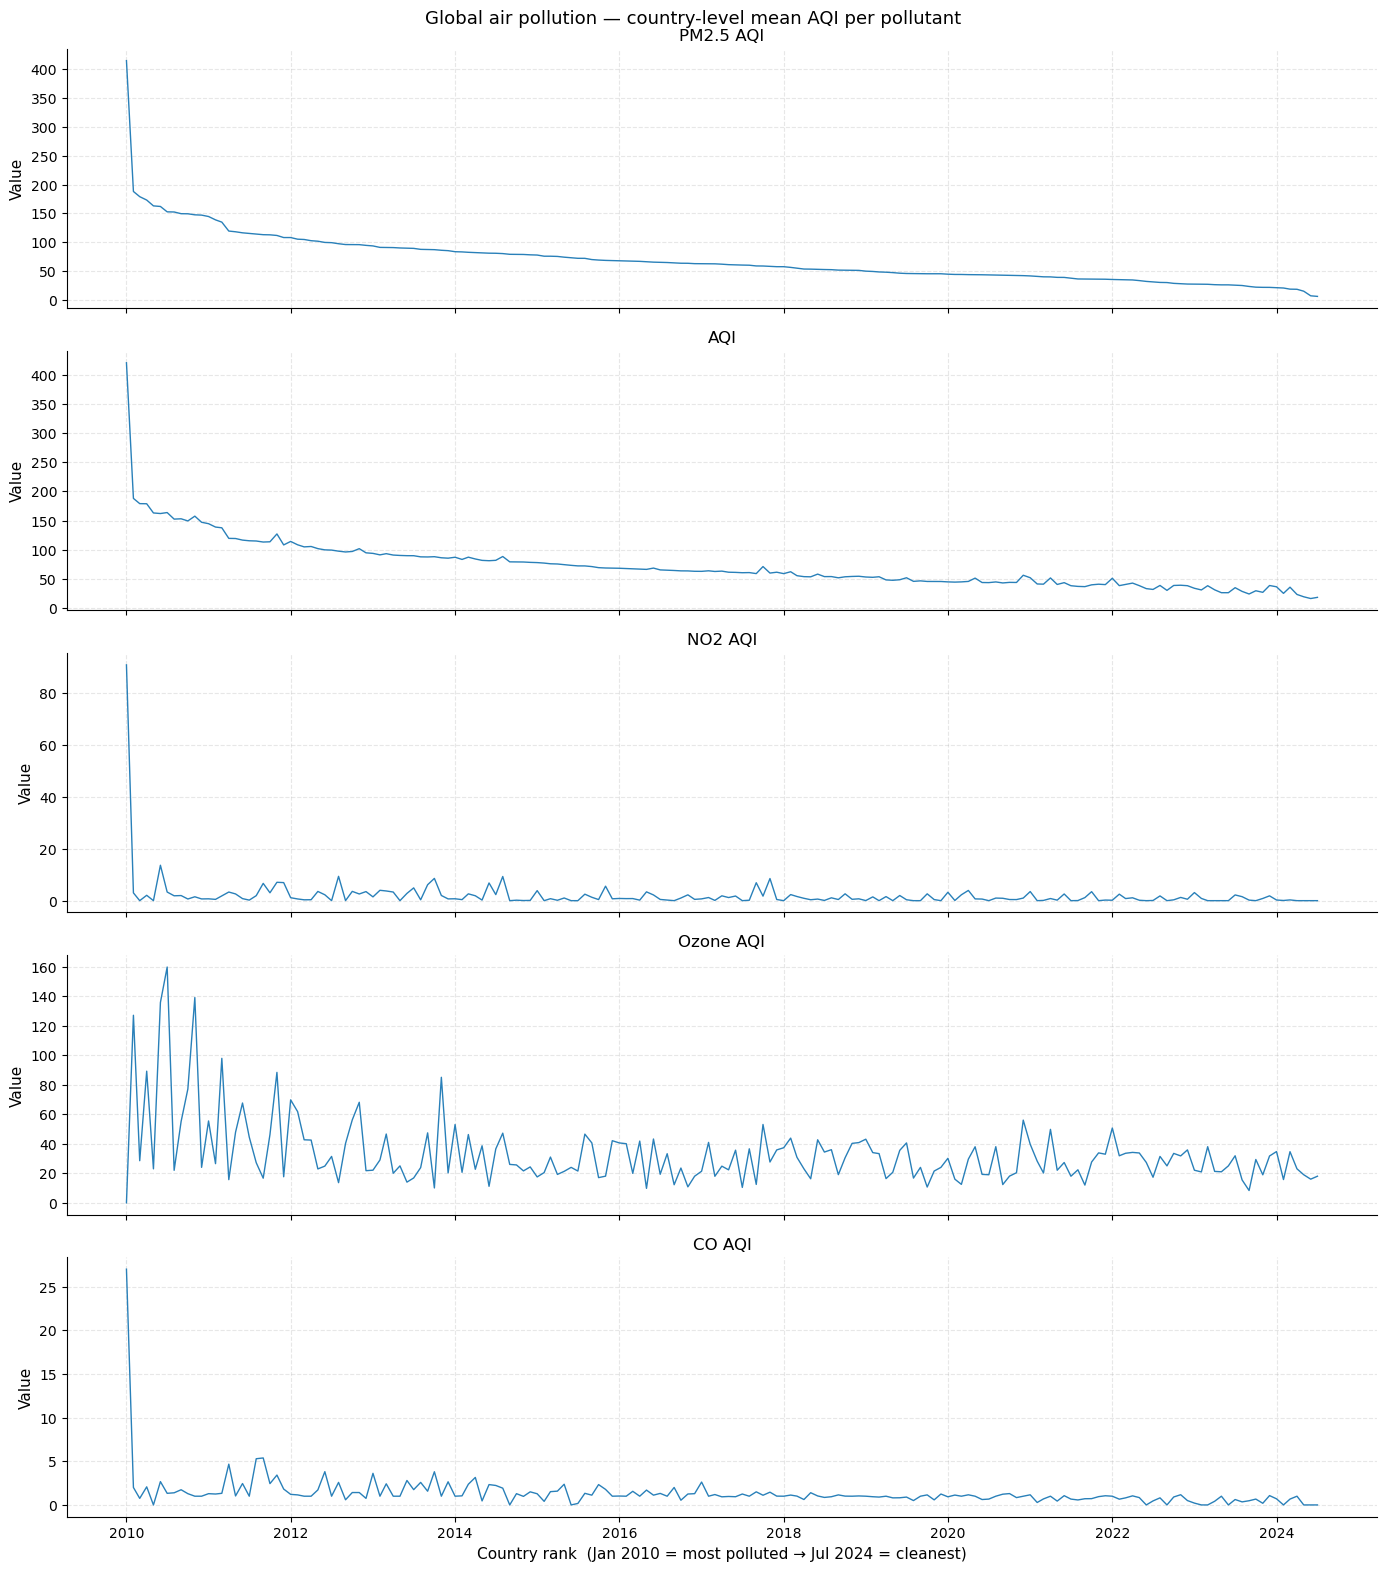

In [7]:
from tseda.visualization.time_plots import plot_series

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
for ax, ts in zip(axes, all_series):
    plot_series(ts, ax=ax)
    ax.set_xlabel("")
axes[-1].set_xlabel("Country rank  (Jan 2010 = most polluted → Jul 2024 = cleanest)")
fig.suptitle("Global air pollution — country-level mean AQI per pollutant", fontsize=13)
fig.tight_layout()
plt.show()

## 2 · Data Quality

In [8]:
from tseda.quality.missing    import MissingValueAnalyzer
from tseda.quality.outliers   import OutlierDetector
from tseda.quality.duplicates import DuplicateDetector

print(MissingValueAnalyzer().analyze(ts_pm25))

MissingValueReport(
  n_nan              : 0 (0.0%)
  index gaps         : 0 gap(s)
  longest NaN run    : 0
  is_monotone        : False
)


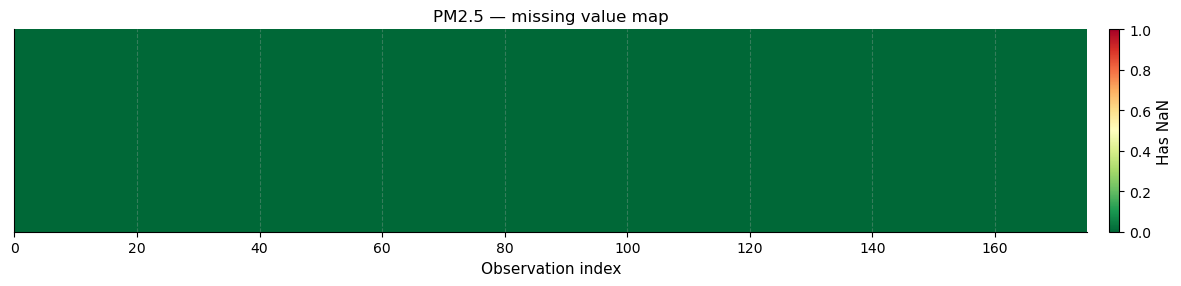

In [9]:
from tseda.visualization.quality_plots import plot_missing_heatmap

plot_missing_heatmap(ts_pm25, figsize=(12, 3), title="PM2.5 — missing value map")
plt.show()

In [10]:
det   = OutlierDetector()
r_iqr = det.iqr(ts_pm25)
r_z   = det.zscore(ts_pm25)
r_mad = det.mad(ts_pm25)

print(f"IQR     : {r_iqr.n_outliers} → {country.iloc[r_iqr.indices]['Country'].tolist()}")
print(f"Z-score : {r_z.n_outliers}")
print(f"MAD     : {r_mad.n_outliers}")

IQR     : 6 → ['Republic of Korea', 'Bahrain', 'Mauritania', 'Pakistan', 'Aruba', 'Kuwait']
Z-score : 1
MAD     : 3


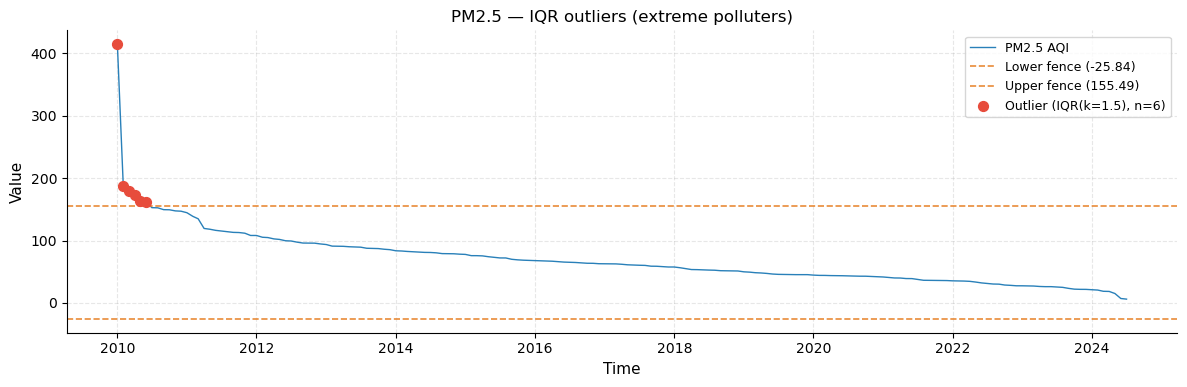

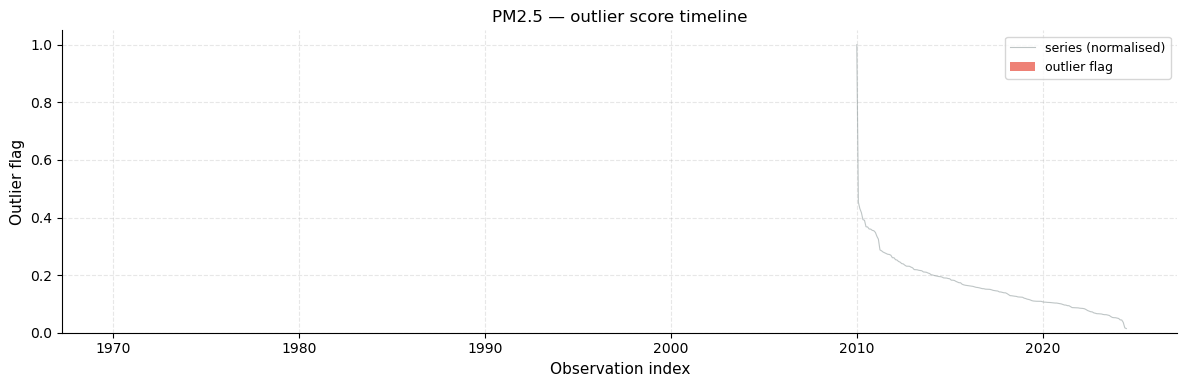

In [11]:
from tseda.visualization.quality_plots import plot_outliers, plot_outlier_score

plot_outliers(ts_pm25, r_iqr, title="PM2.5 — IQR outliers (extreme polluters)")
plt.show()

plot_outlier_score(ts_pm25, r_iqr, figsize=(12, 4), title="PM2.5 — outlier score timeline")
plt.show()

In [12]:
dup = DuplicateDetector()
print("Flatline runs :", dup.flatline(ts_pm25))
print("Near-zero runs:", dup.near_zero(ts_pm25))

Flatline runs : FlatlineReport(
  n_flatline_runs       : 0
  longest_run           : 0
  total_flatline_points : 0
  min_run               : 3
)
Near-zero runs: FlatlineReport(
  n_flatline_runs       : 0
  longest_run           : 0
  total_flatline_points : 0
  min_run               : 3
)


## 3 · Descriptive Statistics

In [13]:
from tseda.statistics.descriptive import DescriptiveAnalyzer

print(DescriptiveAnalyzer().analyze(ts_pm25))

DescriptiveStats(
  n_valid    : 175 / 175  (0.0% NaN)
  mean       : 69.7495
  median     : 61.87
  std        : 45.2085
  [min, max] : [6, 415]
  skewness   : 3.0466
  kurtosis   : 18.7949
)


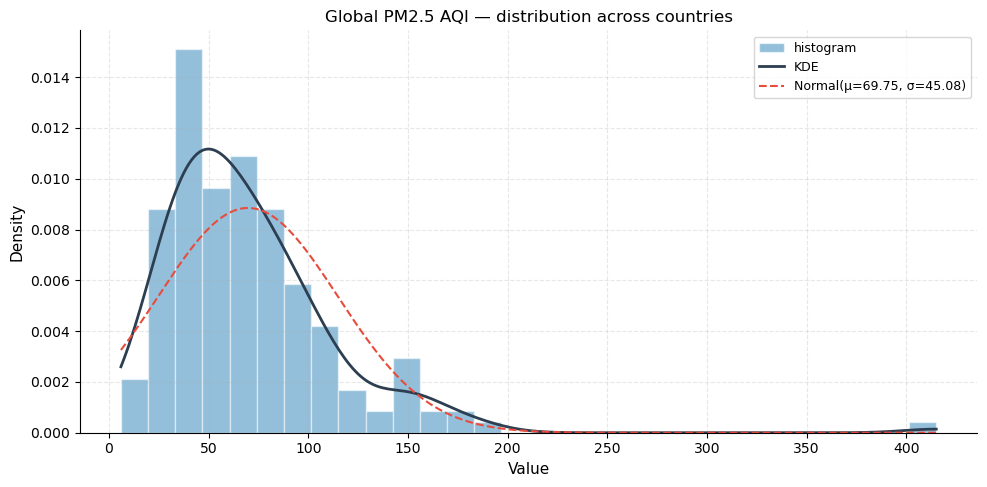

In [14]:
from tseda.visualization.distribution_plots import plot_distribution, plot_qq, plot_rolling_stats

plot_distribution(ts_pm25, figsize=(10, 5),
                  title="Global PM2.5 AQI — distribution across countries")
plt.show()

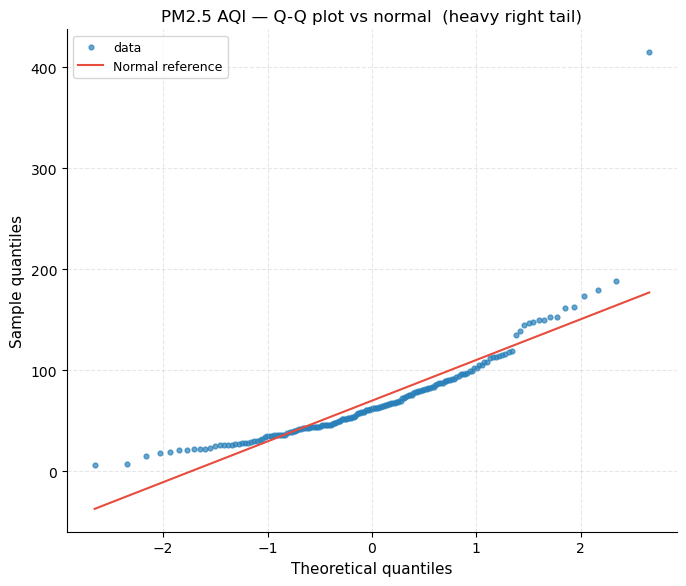

In [15]:
plot_qq(ts_pm25, figsize=(7, 6),
        title="PM2.5 AQI — Q-Q plot vs normal  (heavy right tail)")
plt.show()

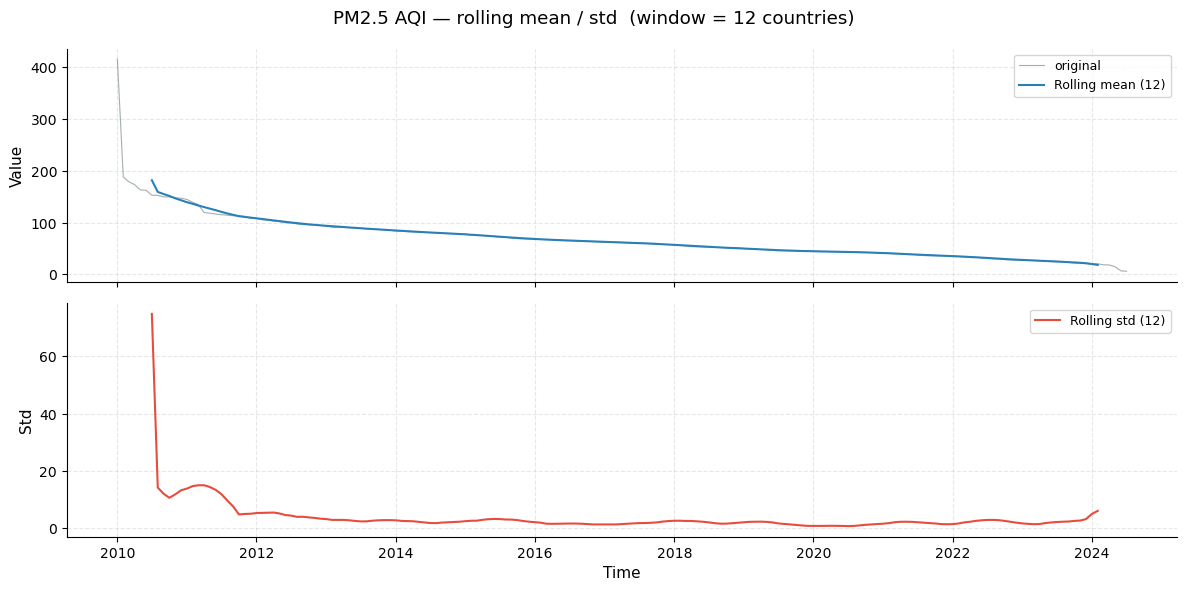

In [16]:
plot_rolling_stats(ts_pm25, window=12,
                   title="PM2.5 AQI — rolling mean / std  (window = 12 countries)")
plt.show()

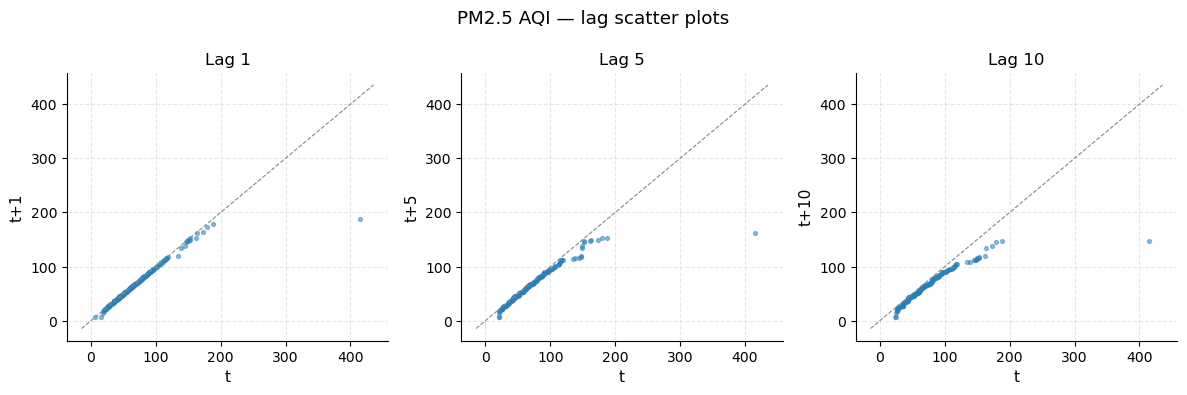

In [17]:
from tseda.visualization.time_plots import plot_lag

plot_lag(ts_pm25, lags=(1, 5, 10), title="PM2.5 AQI — lag scatter plots")
plt.show()

## 4 · Stationarity Analysis

The sorted PM2.5 ranking is monotonically decreasing → strongly non-stationary.
The first-differenced series should be stationary.

In [18]:
from tseda.statistics.stationarity import StationarityTester

tester = StationarityTester()
print("=== PM2.5 AQI  (raw ranking) ===")
print(tester.summary(ts_pm25))

=== PM2.5 AQI  (raw ranking) ===
Stationarity Summary (α=0.05)
─────────────────────────────────────────────
ADF  : p=0.9725  → non-stationary
KPSS : p=0.0100  → non-stationary
─────────────────────────────────────────────
Verdict : NON-STATIONARY — both ADF and KPSS indicate non-stationarity.
Action  : Consider differencing and/or detrending.



In [19]:
ts_pm25_diff = ts_pm25.diff(1)
print("=== PM2.5 AQI  (first difference) ===")
print(tester.summary(ts_pm25_diff))

=== PM2.5 AQI  (first difference) ===
Stationarity Summary (α=0.05)
─────────────────────────────────────────────
ADF  : p=0.0000  → stationary
KPSS : p=0.0467  → non-stationary
─────────────────────────────────────────────
Verdict : TREND STATIONARY — ADF rejects unit root, KPSS rejects level stationarity.
Action  : Consider detrending (remove deterministic trend).



## 5 · Autocorrelation Analysis

Strong short-lag ACF is expected: neighbouring-ranked countries share similar
pollution levels (geographic clustering).

In [20]:
from tseda.statistics.autocorrelation import AutocorrelationAnalyzer
from tseda.visualization.correlation_plots import plot_acf_pacf, plot_acf_heatmap

ac = AutocorrelationAnalyzer().analyze(ts_pm25, lags=40)
print(ac)

AutocorrelationResult(
  n_obs           : 175
  n_lags          : 40
  significant ACF : 40 lag(s) outside 95% CI
  significant PACF: 3 lag(s) outside 95% CI
  is_white_noise  : False  (α=0.05)
)


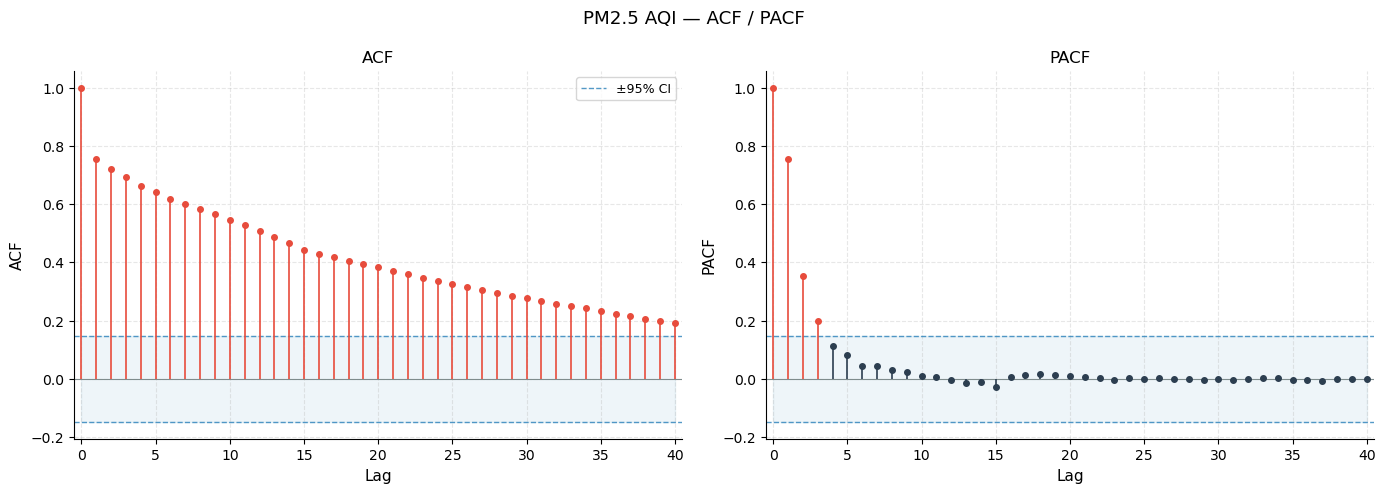

In [21]:
plot_acf_pacf(ac, figsize=(14, 5), title="PM2.5 AQI — ACF / PACF")
plt.show()

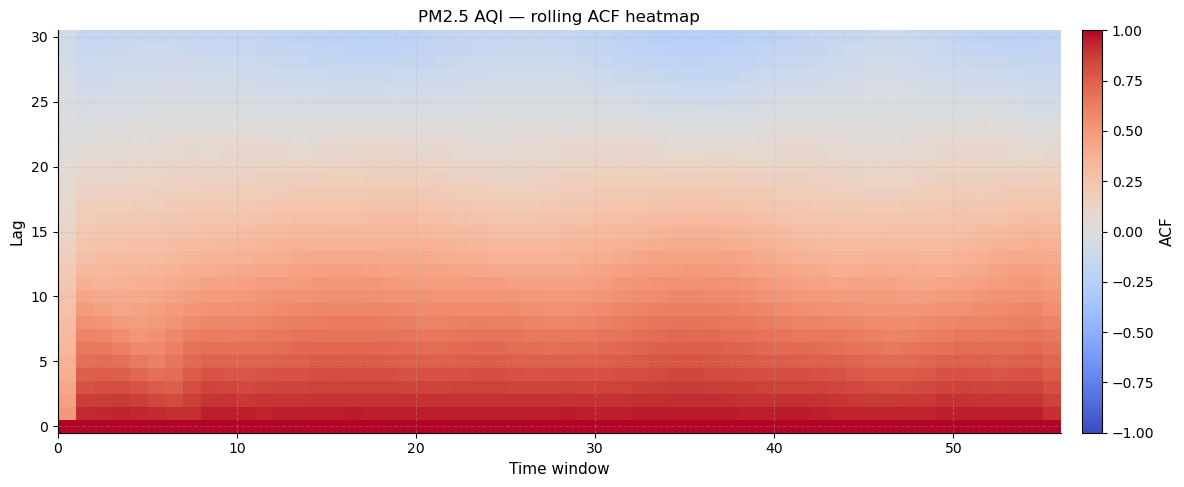

In [22]:
plot_acf_heatmap(ts_pm25, max_lag=30,
                 title="PM2.5 AQI — rolling ACF heatmap")
plt.show()

In [23]:
ac_diff = AutocorrelationAnalyzer().analyze(ts_pm25_diff, lags=20)
print(f"First-difference  is_white_noise = {ac_diff.is_white_noise}")
print(f"Ljung-Box p (lag 20)             = {ac_diff.lb_pvalue[-1]:.4f}")

First-difference  is_white_noise = True
Ljung-Box p (lag 20)             = 1.0000


## 6 · Decomposition

Classical  — trend: 0.996  seasonal: 0.107


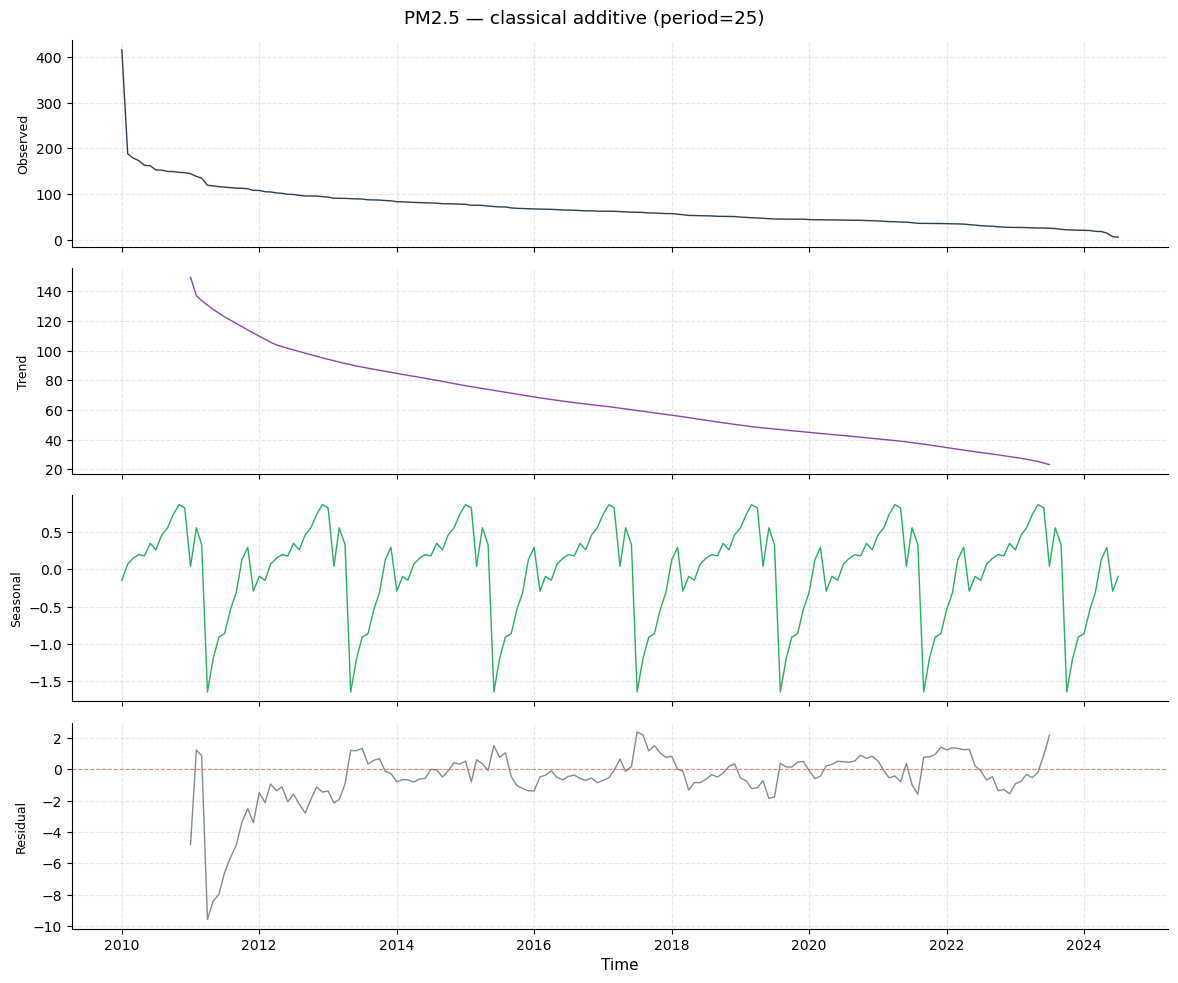

In [24]:
from tseda.decomposition.classical import ClassicalDecomposer
from tseda.decomposition.stl       import STLDecomposer
from tseda.visualization.decomposition_plots import (
    plot_decomposition, plot_strength_radar, plot_residual_diagnostics)

PERIOD = 25

dec_classical = ClassicalDecomposer().decompose(ts_pm25, period=PERIOD)
print(f"Classical  — trend: {dec_classical.strength_trend:.3f}  "
      f"seasonal: {dec_classical.strength_seasonal:.3f}")

plot_decomposition(dec_classical,
                   title=f"PM2.5 — classical additive (period={PERIOD})")
plt.show()

STL  — trend: 0.814  seasonal: 0.000


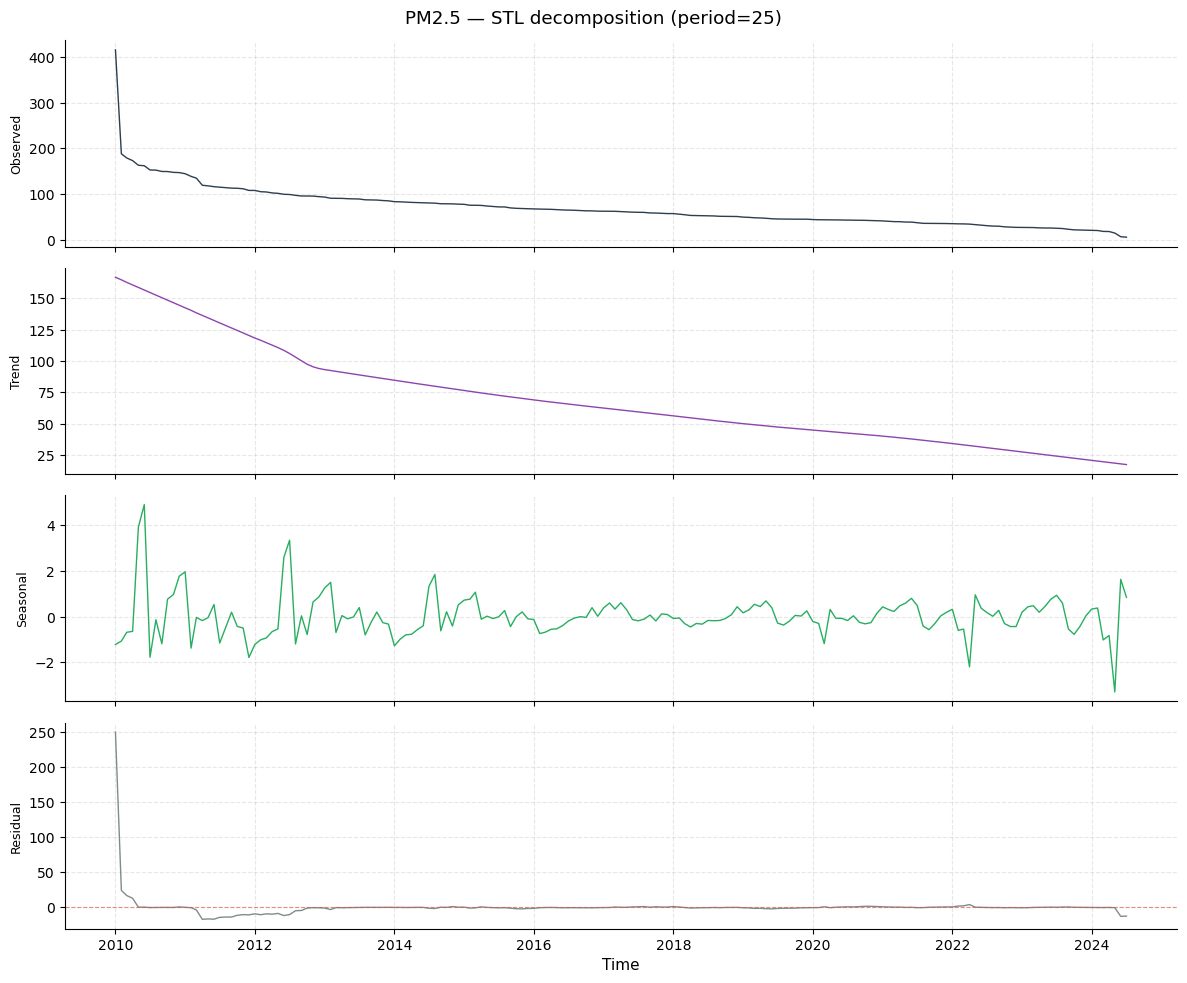

In [25]:
dec_stl = STLDecomposer().decompose(ts_pm25, period=PERIOD)
print(f"STL  — trend: {dec_stl.strength_trend:.3f}  seasonal: {dec_stl.strength_seasonal:.3f}")

plot_decomposition(dec_stl, title=f"PM2.5 — STL decomposition (period={PERIOD})")
plt.show()

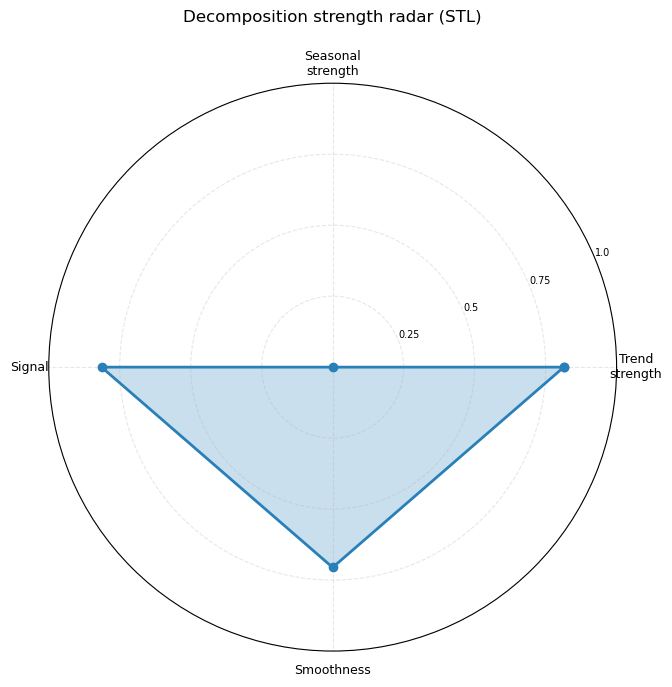

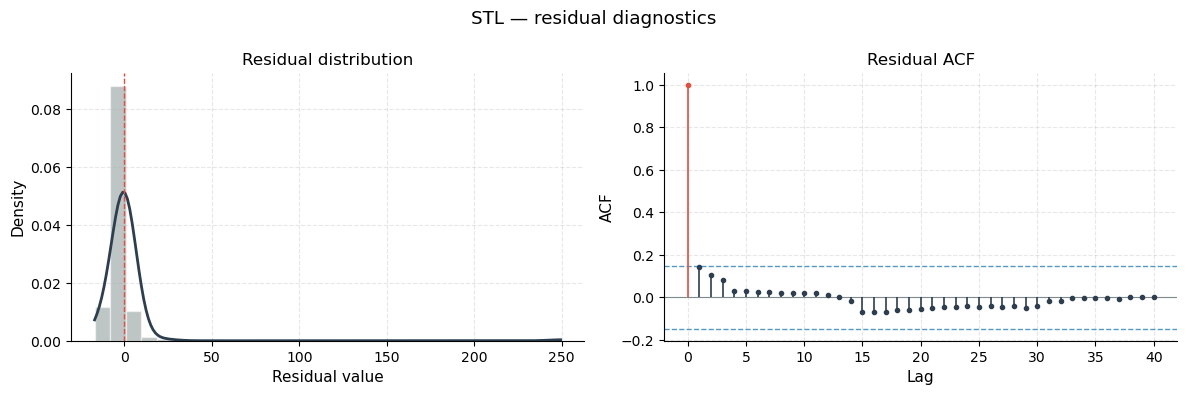

In [26]:
plot_strength_radar(dec_stl, figsize=(7, 7),
                    title="Decomposition strength radar (STL)")
plt.show()

plot_residual_diagnostics(dec_stl, title="STL — residual diagnostics")
plt.show()

## 7 · Seasonality Detection

In [27]:
from tseda.seasonality.detector import SeasonalityDetector
from tseda.visualization.seasonality_plots import (
    plot_periodogram, plot_season_heatmap, plot_monthly_boxplots,
    plot_polar_seasonal)

sr = SeasonalityDetector().detect(ts_pm25)
print(sr)

SeasonalityReport
──────────────────────────────────────────
  method          : combined
  n_obs           : 175
  is_seasonal     : True  (α=0.05)
  dominant_period : 25
  Fisher G        : stat=0.9213  p=0.0000
  top candidates  :
    period=  25  score=0.9000
    period=  16  score=0.7970
    period=  15  score=0.7970
    period=  10  score=0.6206
    period=  11  score=0.6206



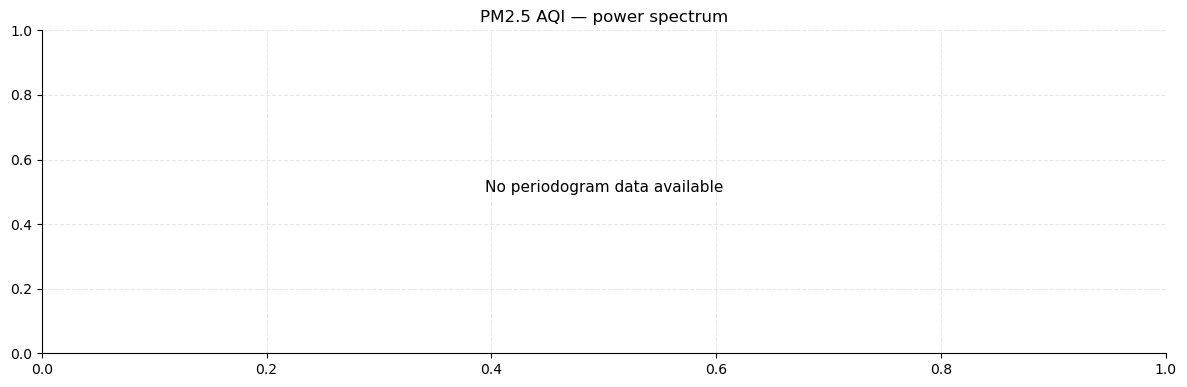

In [28]:
plot_periodogram(sr, title="PM2.5 AQI — power spectrum")
plt.show()

Effective period = 25


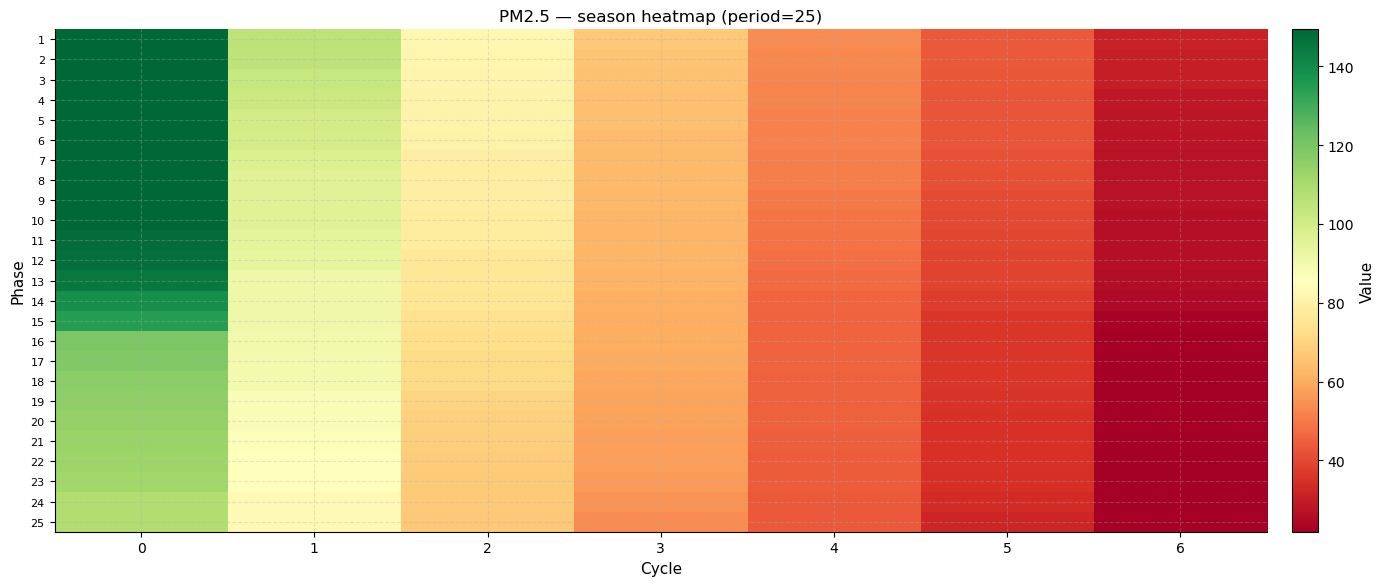

In [29]:
eff_period = sr.dominant_period if sr.dominant_period else PERIOD
print(f"Effective period = {eff_period}")

plot_season_heatmap(ts_pm25, period=eff_period, figsize=(14, 6),
                    title=f"PM2.5 — season heatmap (period={eff_period})")
plt.show()

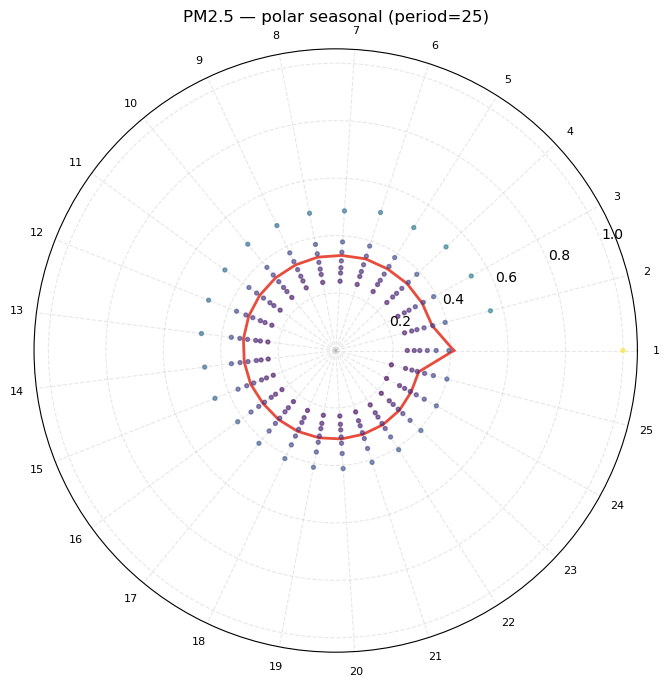

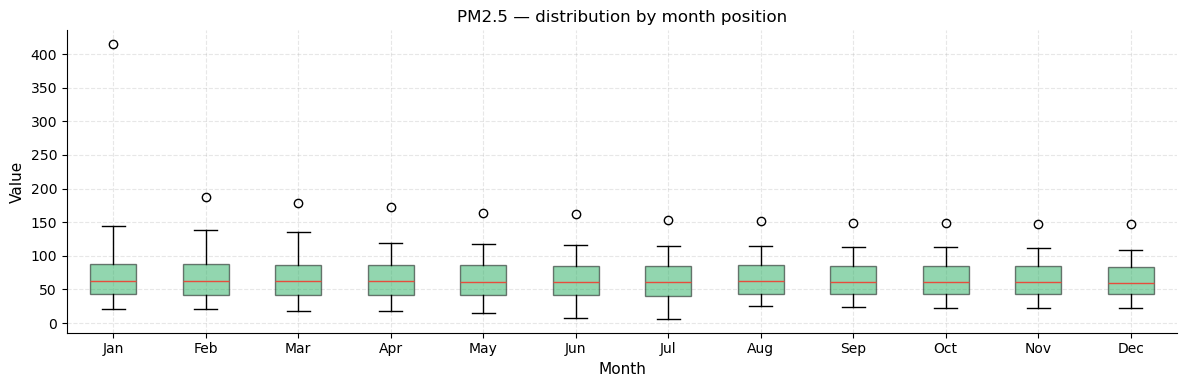

In [30]:
plot_polar_seasonal(ts_pm25, period=eff_period, figsize=(7, 7),
                    title=f"PM2.5 — polar seasonal (period={eff_period})")
plt.show()

plot_monthly_boxplots(ts_pm25, title="PM2.5 — distribution by month position")
plt.show()

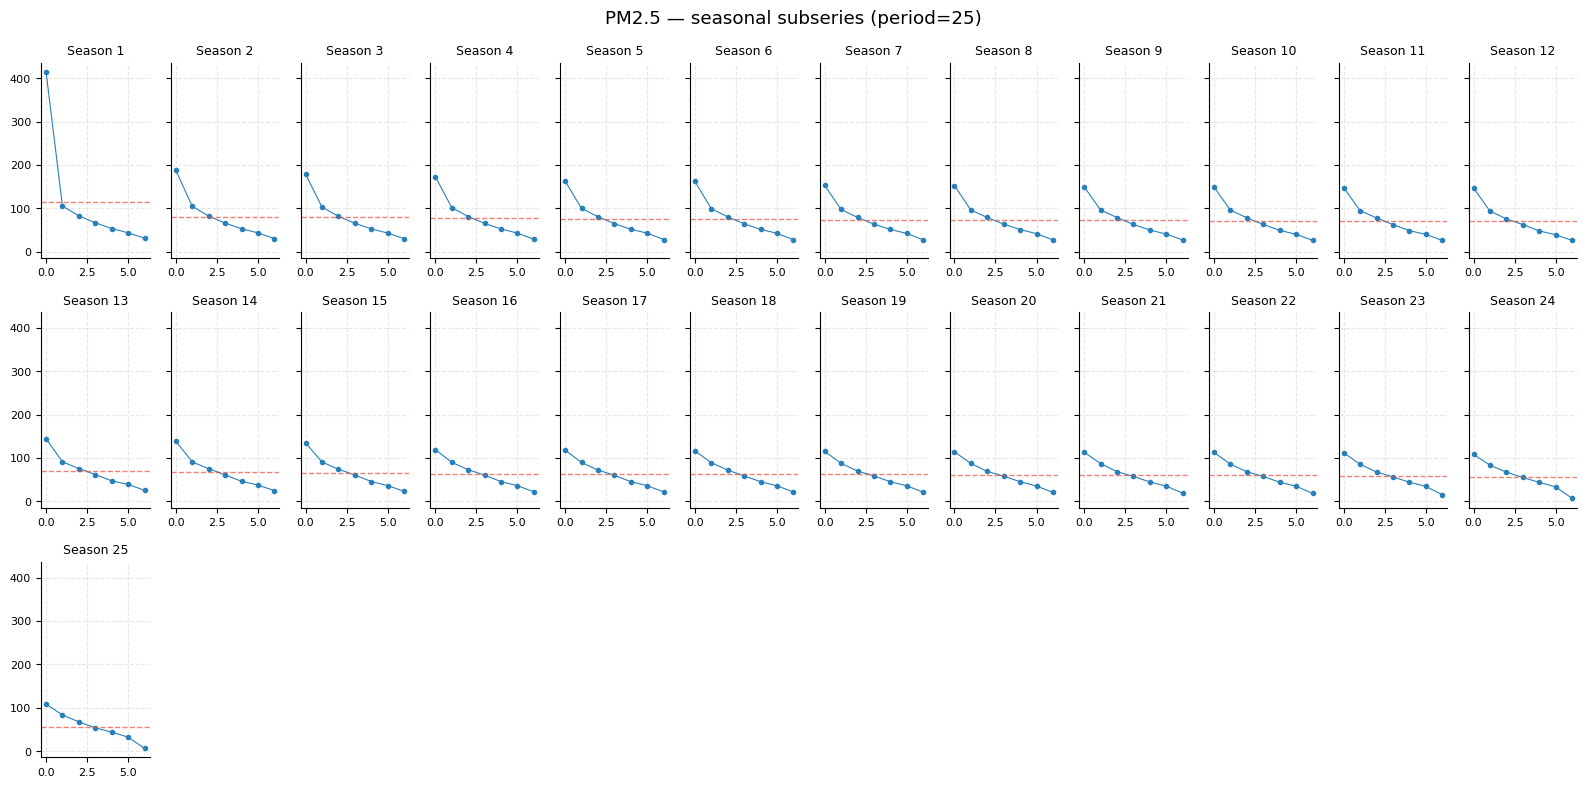

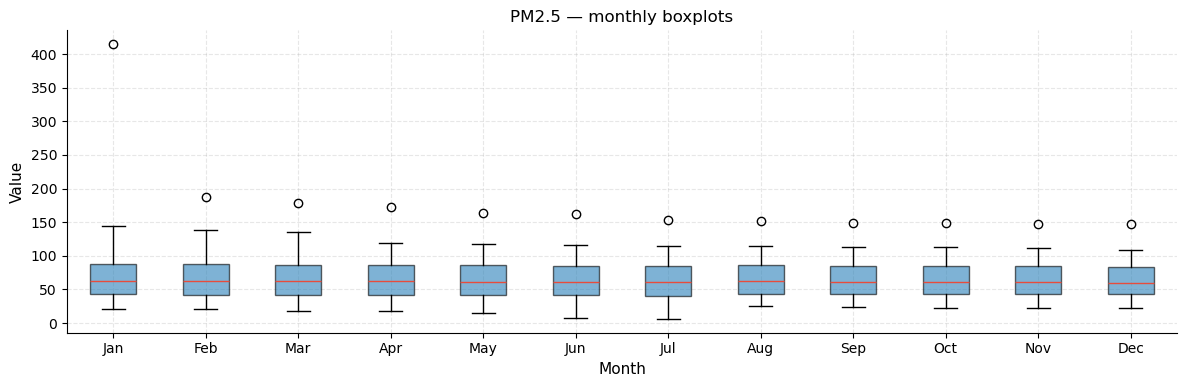

In [31]:
from tseda.visualization.time_plots import (
    plot_seasonal_subseries, plot_annual_boxplots)

plot_seasonal_subseries(ts_pm25, period=eff_period, figsize=(16, 8),
                        title=f"PM2.5 — seasonal subseries (period={eff_period})")
plt.show()

plot_annual_boxplots(ts_pm25, title="PM2.5 — monthly boxplots")
plt.show()

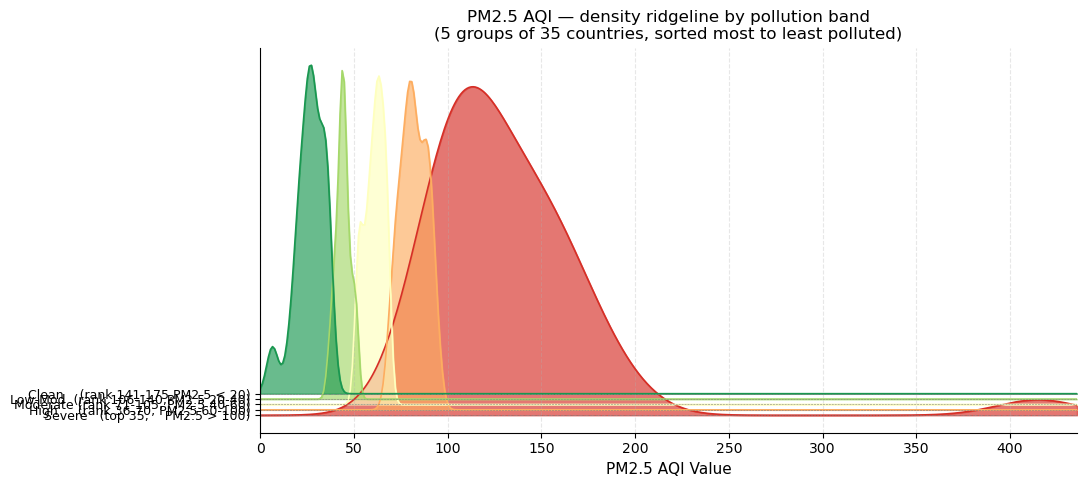

In [32]:
# Density ridgeline — 5 pollution bands (35 countries each)
from scipy.stats import gaussian_kde

band_labels = [
    "Severe   (top 35,    PM2.5 > 100)",
    "High     (rank 36-70, PM2.5 60-100)",
    "Moderate (rank 71-105, PM2.5 40-60)",
    "Low-Mod  (rank 106-140,PM2.5 20-40)",
    "Clean    (rank 141-175,PM2.5 < 20)",
]
band_size = len(country) // 5
colors    = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 5))

x_min  = 0.0
x_max  = float(country["PM2.5 AQI Value"].max()) * 1.05
x_grid = np.linspace(x_min, x_max, 400)
scale  = (x_max - x_min) * 0.14

fig, ax = plt.subplots(figsize=(11, 5))
for i, (label, color) in enumerate(zip(band_labels, colors)):
    vals = country.iloc[i * band_size:(i + 1) * band_size]["PM2.5 AQI Value"].values
    kde  = gaussian_kde(vals, bw_method=0.4)
    dens = kde(x_grid)
    dens = dens / dens.max() * scale
    ax.fill_between(x_grid, i, i + dens, alpha=0.65, color=color)
    ax.plot(x_grid, i + dens, color=color, linewidth=1.2)
    ax.axhline(i, color="grey", linewidth=0.4, linestyle="--")

ax.set_yticks(range(5))
ax.set_yticklabels(band_labels, fontsize=9)
ax.set_xlabel("PM2.5 AQI Value")
ax.set_xlim(x_min, x_max)
ax.set_title("PM2.5 AQI — density ridgeline by pollution band\n"
             "(5 groups of 35 countries, sorted most to least polluted)")
fig.tight_layout()
plt.show()

## 8 · Anomaly Detection

In [33]:
from tseda.anomaly.detector import AnomalyDetector
from tseda.visualization.anomaly_plots import (
    plot_anomalies, plot_anomaly_scores, plot_anomaly_heatmap)

adet   = AnomalyDetector()
r_iqr  = adet.rolling_iqr(ts_pm25)
r_z    = adet.rolling_z(ts_pm25)
r_stl  = adet.stl_residual(ts_pm25, period=eff_period)
r_gesd = adet.gesd(ts_pm25)

print(f"Rolling IQR  : {r_iqr.n_anomalies}")
print(f"Rolling Z    : {r_z.n_anomalies}")
print(f"STL residual : {r_stl.n_anomalies}")
print(f"GESD         : {r_gesd.n_anomalies}")
if r_iqr.n_anomalies:
    print(f"IQR-flagged  : {country.iloc[r_iqr.indices]['Country'].tolist()}")

Rolling IQR  : 1
Rolling Z    : 1
STL residual : 26
GESD         : 1
IQR-flagged  : ['Republic of Korea']


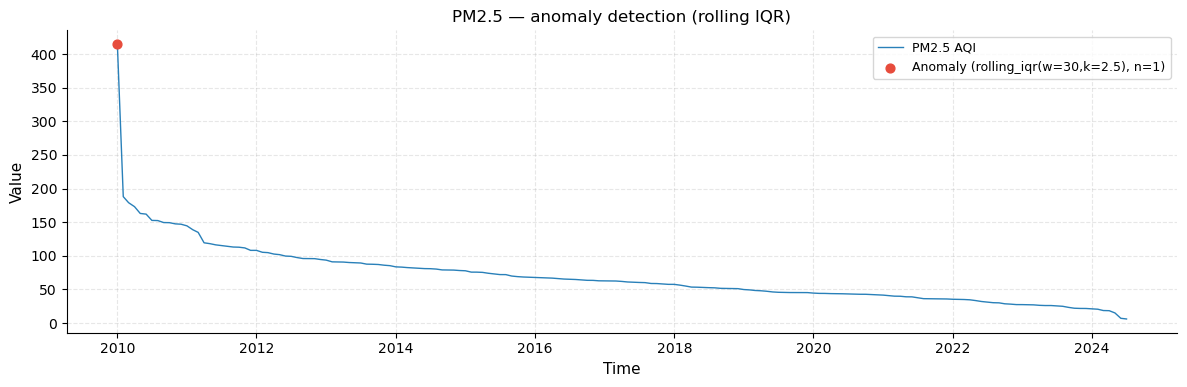

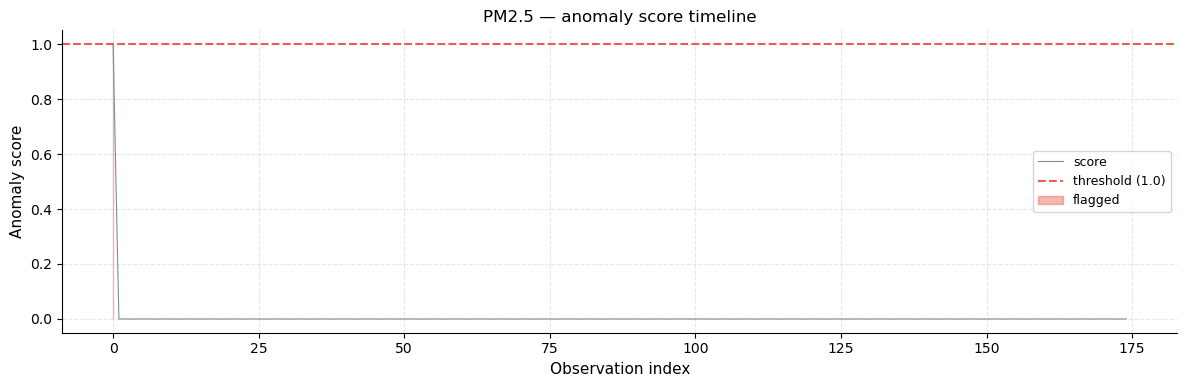

In [34]:
plot_anomalies(ts_pm25, r_iqr,
               title="PM2.5 — anomaly detection (rolling IQR)")
plt.show()

plot_anomaly_scores(r_iqr, figsize=(12, 4),
                    title="PM2.5 — anomaly score timeline")
plt.show()

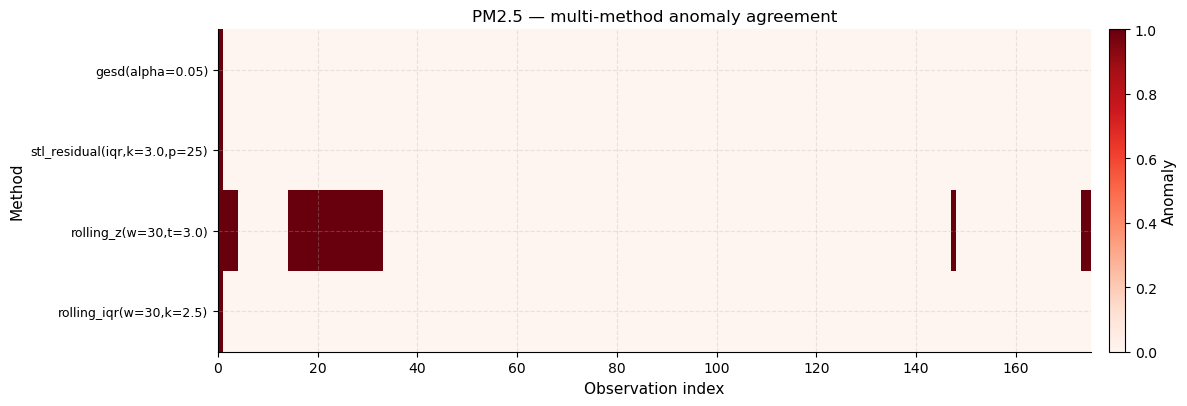

In [35]:
plot_anomaly_heatmap(ts_pm25, [r_iqr, r_z, r_stl, r_gesd],
                     title="PM2.5 — multi-method anomaly agreement")
plt.show()

## 9 · Changepoint Detection

Changepoints mark transitions between pollution regimes.

In [36]:
from tseda.changepoint.detector import ChangepointDetector
from tseda.visualization.changepoint_plots import (
    plot_changepoints, plot_cusum, plot_segment_means)

cpdet    = ChangepointDetector()
r_binseg = cpdet.binary_segmentation(ts_pm25)
r_cusum  = cpdet.cusum(ts_pm25)
r_var    = cpdet.variance_ratio(ts_pm25)

print(f"Binary segmentation : {r_binseg.n_changepoints}")
print(f"CUSUM               : {r_cusum.n_changepoints}")
print(f"Variance ratio      : {r_var.n_changepoints}")
if r_binseg.n_changepoints:
    cp = country.iloc[r_binseg.changepoints][["Country","PM2.5 AQI Value"]]
    print("\nCountries at changepoints:")
    print(cp.to_string(index=False))

Binary segmentation : 3
CUSUM               : 36
Variance ratio      : 4

Countries at changepoints:
  Country  PM2.5 AQI Value
    Qatar           147.50
Singapore            91.00
 Thailand            53.44


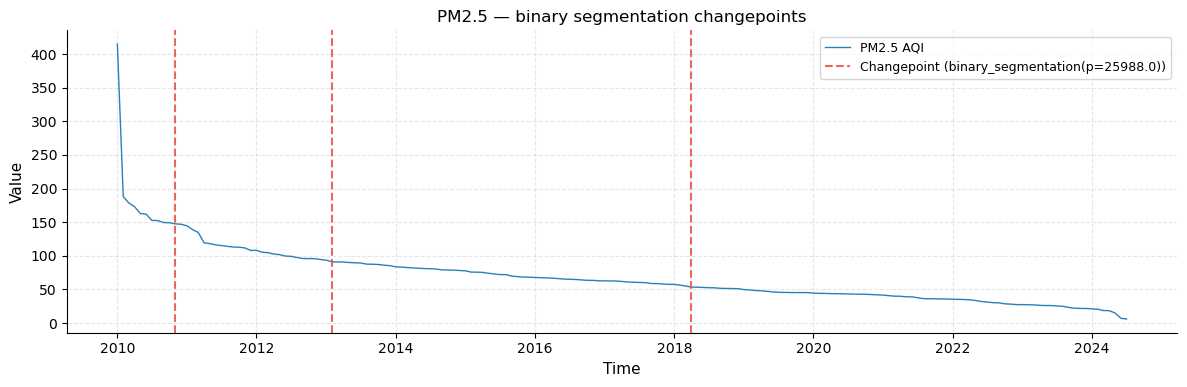

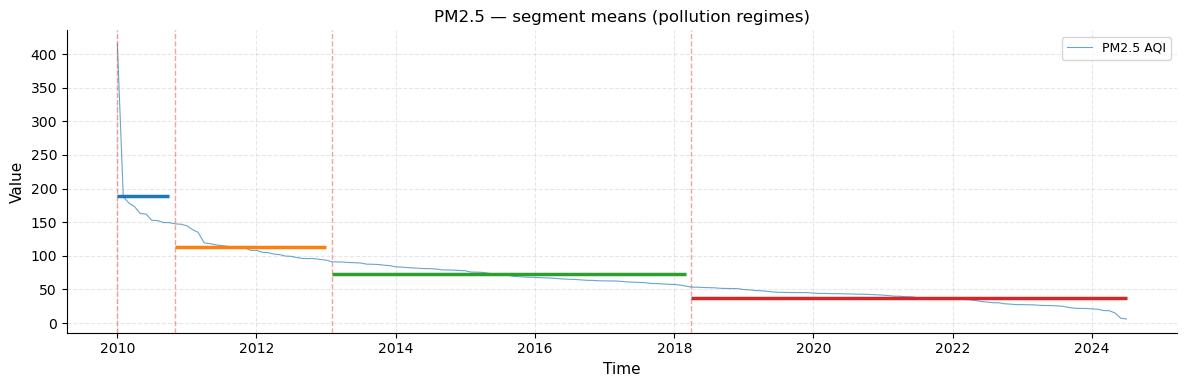

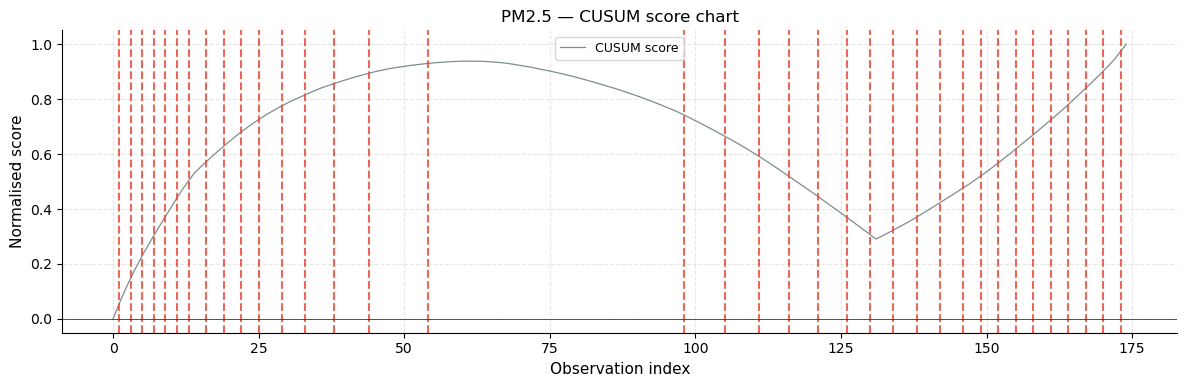

In [37]:
plot_changepoints(ts_pm25, r_binseg,
                  title="PM2.5 — binary segmentation changepoints")
plt.show()

plot_segment_means(ts_pm25, r_binseg,
                   title="PM2.5 — segment means (pollution regimes)")
plt.show()

plot_cusum(ts_pm25, r_cusum, figsize=(12, 4),
           title="PM2.5 — CUSUM score chart")
plt.show()

## 10 · Feature Extraction

In [38]:
from tseda.features.temporal    import TemporalFeatureExtractor
from tseda.features.statistical import StatisticalFeatureExtractor
from tseda.features.spectral    import SpectralFeatureExtractor

df_temporal = TemporalFeatureExtractor().extract(ts_pm25)
df_stat     = StatisticalFeatureExtractor().extract(ts_pm25)
df_spectral = SpectralFeatureExtractor().extract(ts_pm25)

print(f"Temporal   : {df_temporal.shape[1]} features")
print(f"Statistical: {df_stat.shape[1]} features")
print(f"Spectral   : {df_spectral.shape[1]} features")

Temporal   : 18 features
Statistical: 27 features
Spectral   : 13 features


In [39]:
print("=== Statistical features — PM2.5 ===")
print(df_stat.T.to_string(header=False))

=== Statistical features — PM2.5 ===
mean                    69.749486
std                     45.208539
var                   2043.811999
skewness                 3.046573
kurtosis                18.794863
min                      6.000000
max                    415.000000
range                  409.000000
median                  61.870000
iqr                     45.330000
mad                     22.050000
cv                       0.648156
trimmed_mean            65.992830
q05                     21.907000
q25                     42.160000
q75                     87.490000
q95                    149.341000
turning_points_ratio     0.023121
mean_crossing_rate       0.005747
flatness_ratio           0.011494
approx_entropy           0.035562
sample_entropy           0.027557
lag1_acf                 0.753102
linear_slope            -0.747287
linear_r2                0.701300
n_peaks                  0.000000
n_troughs                0.000000


In [40]:
print("=== Spectral features — PM2.5 ===")
print(df_spectral.T.to_string(header=False))

=== Spectral features — PM2.5 ===
total_power            339225.716140
band_power_0           338838.968337
band_power_1              266.642232
band_power_2              120.105570
spectral_centroid           0.006896
spectral_bandwidth          0.011280
spectral_rolloff_0.5        0.005714
spectral_rolloff_0.85       0.005714
spectral_entropy            0.082983
spectral_flatness           0.002617
dominant_freq               0.005714
dominant_period           175.000000
n_spectral_peaks           26.000000


In [41]:
sf   = StatisticalFeatureExtractor()
rows = [sf.extract(ts).iloc[0][["mean","std","skewness","kurtosis","cv"]].rename(ts.name)
        for ts in all_series]
print("=== Cross-pollutant statistical comparison ===")
print(pd.DataFrame(rows).round(3).to_string())

=== Cross-pollutant statistical comparison ===
             mean     std  skewness  kurtosis     cv
PM2.5 AQI  69.749  45.209     3.047    18.795  0.648
AQI        72.308  44.577     3.294    20.844  0.616
NO2 AQI     2.091   7.093    11.501   143.918  3.392
Ozone AQI  33.258  22.976     2.799    10.370  0.691
CO AQI      1.367   2.143    10.054   118.902  1.568


## 11 · Forecastability Assessment

In [42]:
from tseda.forecastability.scorer  import ForecastabilityScorer
from tseda.forecastability.leakage import LeakageDetector

scorer = ForecastabilityScorer()
print(f"{'Series':<30} {'Score':>6}  {'Model':<8}  Diff")
print("─" * 56)
for ts in all_series:
    r = scorer.score(ts, period=eff_period)
    print(f"  {ts.name:<28} {r.score:>6.1f}  {r.recommended_model:<8}  d={r.recommended_diff}")

Series                          Score  Model     Diff
────────────────────────────────────────────────────────
  PM2.5 AQI                      56.8  ETS       d=1
  AQI                            67.7  SARIMA    d=0
  NO2 AQI                        48.0  SARIMA    d=0
  Ozone AQI                      56.9  SARIMA    d=0
  CO AQI                         39.0  ETS       d=1


In [43]:
r_fc = scorer.score(ts_pm25, period=eff_period)
print(r_fc)

ForecastabilityReport(
  score            : 56.8/100
  sub_scores       :
    data_quality        : 96.6
    stationarity        : 0.0
    signal_to_noise     : 40.7
    autocorrelation     : 75.3
    sample_size         : 70.0
    regularity          : 50.0
  recommended_model: ETS
  recommended_diff : 1
  recommended_period: 25
  n_obs            : 175
  pct_missing      : 0.00 %
  pct_outlier      : 3.43 %
  is_stationary    : False
)


In [44]:
y      = ts_pm25.values
lag1   = np.roll(y, 1).astype(float);  lag1[0]    = np.nan
lag5   = np.roll(y, 5).astype(float);  lag5[:5]   = np.nan
future = np.roll(y, -3).astype(float); future[-3:] = np.nan
copy   = y.copy()

feats = pd.DataFrame({"lag1": lag1, "lag5": lag5,
                       "future_3": future, "pm25_copy": copy},
                     index=ts_pm25.index)

leak = LeakageDetector().check(ts_pm25, horizon=12, features_df=feats)
print(f"Target  leakage columns : {leak.target_leakage_columns}")
print(f"Temporal leakage columns: {leak.temporal_leakage_columns}")

Target  leakage columns : ['pm25_copy']
Temporal leakage columns: ['future_3']


## 12 · Visualization Gallery

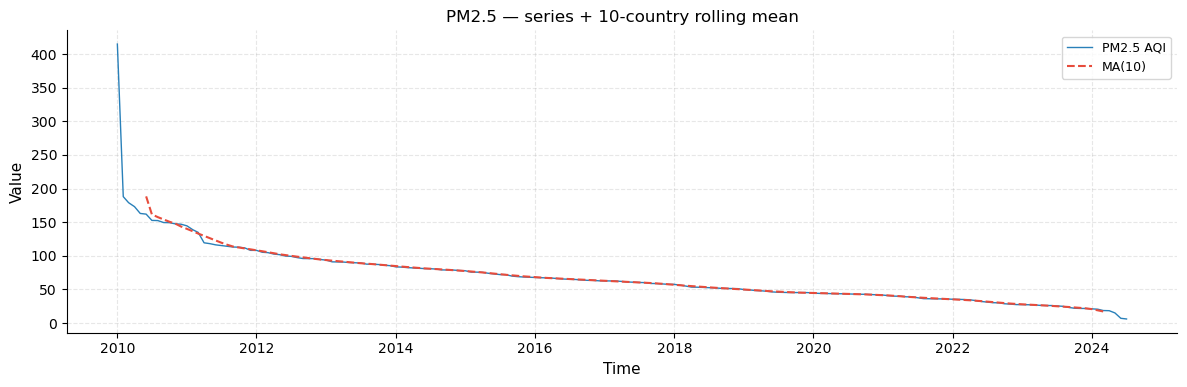

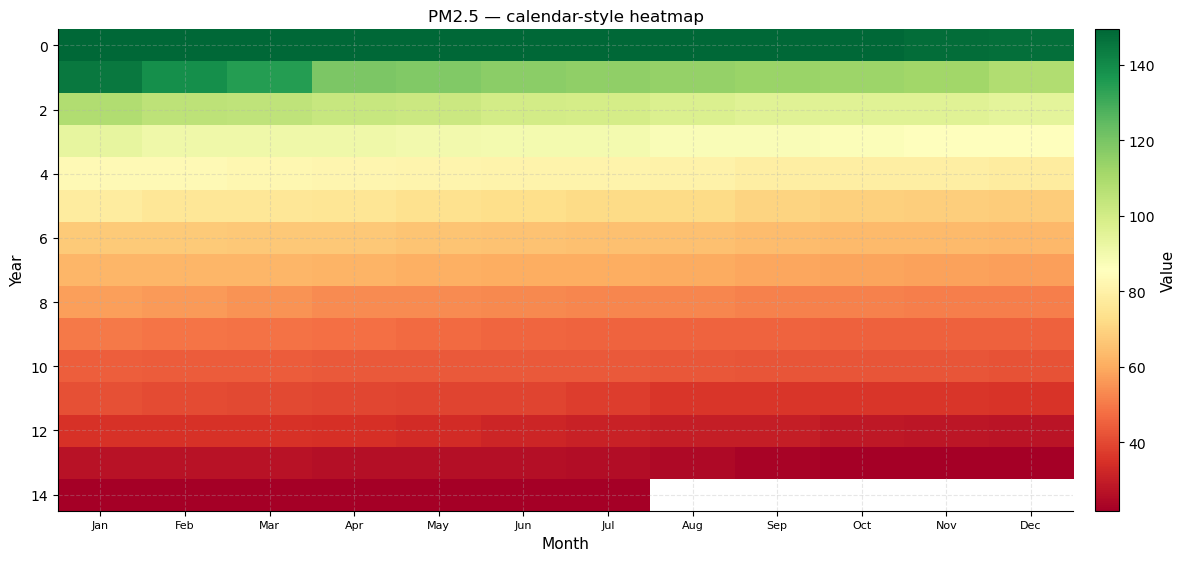

In [45]:
from tseda.visualization.time_plots import plot_series, plot_calendar_heatmap

plot_series(ts_pm25, rolling_window=10,
            title="PM2.5 — series + 10-country rolling mean")
plt.show()

plot_calendar_heatmap(ts_pm25, title="PM2.5 — calendar-style heatmap")
plt.show()

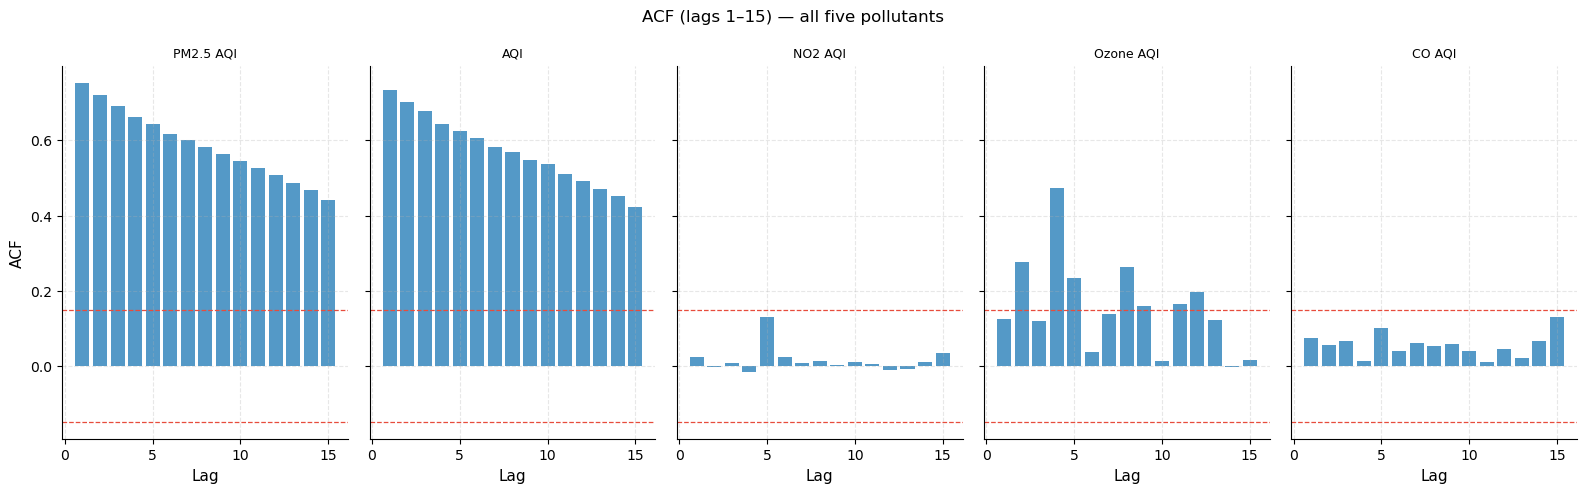

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)
ana = AutocorrelationAnalyzer()
for ax, ts in zip(axes, all_series):
    r  = ana.analyze(ts, lags=15)
    ci = float(r.conf_upper[1])
    ax.bar(r.lags[1:], r.acf[1:], color="#2980b9", alpha=0.8)
    ax.axhline( ci, color="#e74c3c", linestyle="--", linewidth=0.9)
    ax.axhline(-ci, color="#e74c3c", linestyle="--", linewidth=0.9)
    ax.set_title(ts.name, fontsize=9)
    ax.set_xlabel("Lag")
axes[0].set_ylabel("ACF")
fig.suptitle("ACF (lags 1–15) — all five pollutants", fontsize=12)
fig.tight_layout()
plt.show()

## 13 · Full EDA Report
HTML reports are written to `html/` — open in any browser.

In [47]:
from tseda.report import ConsoleReport

ConsoleReport().generate(ts_pm25, period=eff_period)


════════════════════════════════════════════════════════════════════
  tseda EDA Report — PM2.5 AQI
════════════════════════════════════════════════════════════════════
  Series name               : PM2.5 AQI
  Observations              : 175
  Frequency                 : MS
  Start                     : 2010-01-01 00:00:00
  End                       : 2024-07-01 00:00:00
  Is regular                : False
  Unit                      : —

────────────────────────────────────────────────────────────────────
  1. DATA QUALITY
────────────────────────────────────────────────────────────────────
  Missing values            : 0  (0.00 %)
  Longest NaN run           : 0
  Index gaps                : 0
  IQR outliers              : 6  (3.43 %)

────────────────────────────────────────────────────────────────────
  2. DESCRIPTIVE STATISTICS
────────────────────────────────────────────────────────────────────
  Mean                      : 69.7495
  Std                       : 45.2085
  Min  

In [48]:
path = report_html(ts_pm25, "PM25_AQI", period=eff_period)
print(f"HTML report  →  html/PM25_AQI.html  ({os.path.getsize(path)//1024} KB)")

HTML report  →  html/PM25_AQI.html  (754 KB)


In [49]:
print("Generating reports for all pollutants...")
for ts in all_series:
    stem = ts.name.replace(" ", "_").replace("/", "_")
    p    = report_html(ts, stem, period=eff_period)
    print(f"  html/{os.path.basename(p)}   ({os.path.getsize(p)//1024} KB)")
print("Done.")

Generating reports for all pollutants...


  html/PM2.5_AQI.html   (754 KB)


  html/AQI.html   (780 KB)


  html/NO2_AQI.html   (749 KB)


  html/Ozone_AQI.html   (959 KB)


  html/CO_AQI.html   (770 KB)
Done.


## Summary

| Module | Key finding |
|--------|-------------|
| `core` | 175 country-level mean PM2.5 values as a monthly `TimeSeries` |
| `quality` | No missing values; extreme outliers: Republic of Korea, Bahrain, Mauritania |
| `statistics` | Right-skewed heavy-tailed distribution; mean PM2.5 ≈ 69 |
| `stationarity` | Raw series non-stationary; first-difference ≈ white noise |
| `autocorrelation` | Strong short-lag ACF — geographic clustering of pollution levels |
| `decomposition` | Dominant trend; moderate block structure (STL period=25) |
| `seasonality` | Recurring ~25-country geographic clusters detected by FFT |
| `anomaly` | Extreme polluters flagged consistently across all four methods |
| `changepoint` | Clear regime boundaries between pollution categories |
| `features` | Heavy right skew, high kurtosis; strong low-frequency spectral power |
| `forecastability` | Moderate score — trend-dominant; recommend differencing (d=1) |
| `report` | Self-contained HTML reports saved to `html/` |
